# Exoplanet Detection using Light Curve Analysis

## Overview
This notebook demonstrates an astronomical data analysis problem using Python and relevant techniques.

## Objective
- Analyze stellar light curves
- Detect periodic dips
- Estimate orbital period


In [ ]:
!pip install lightkurve
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
star_name = input("Enter star name: ")
mission_name = input("Enter mission name: ")

Enter star name: Kepler-10
Enter mission name: Kepler


In [ ]:
orbital_time_str = input("Enter orbital period in days: ")
if orbital_time_str.strip() == "":
    user_period = None
else:
    user_period = float(orbital_time_str)

Enter orbital period in days: 


In [ ]:
search_result = lk.search_lightcurve(star_name, mission=mission_name)
lc = search_result.download()

/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 50 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


In [ ]:
lc.head()

time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
200.32408500967722,5.5696000e+05,1.1305735e+02,0,2.622170e-03,655.63318,250.32889,122650,5.5629538e+05,1.1105357e+02,3.4163665e+03,6.7321736e-01,5.5696000e+05,1.1305735e+02,0,———,———,———,———,655.63318,2.0087537e-04,250.32889,2.8624298e-04,-8.9440849e-03,3.7062202e-02
200.3247661127025,5.5708588e+05,1.1307109e+02,0,2.622173e-03,655.63361,250.32593,122651,5.5642056e+05,1.1106165e+02,3.4168267e+03,6.7319971e-01,5.5708588e+05,1.1307109e+02,0,———,———,———,———,655.63361,2.0079174e-04,250.32593,2.8616333e-04,-8.9426376e-03,3.7056953e-02
200.32544721572776,5.5703188e+05,1.1307073e+02,0,2.622176e-03,655.63319,250.32772,122652,5.5636775e+05,1.1105553e+02,3.4172874e+03,6.7318219e-01,5.5703188e+05,1.1307073e+02,0,———,———,———,———,655.63319,2.0085592e-04,250.32772,2.8623262e-04,-8.9411894e-03,3.7051704e-02
200.32612831898587,5.5684444e+05,1.1306761e+02,0,2.622179e-03,655.63277,250.32793,122653,5.5618300e+05,1.1104655e+02,3.4177478e+03,6.7316467e-01,5.5684444e+05,1.1306761e+02,0,———,———,———,———,655.63277,2.0090178e-04,250.32793,2.8624505e-04,-8.9397421e-03,3.7046455e-02
200.3268094220184,5.5680788e+05,1.1306657e+02,0,2.622182e-03,655.63314,250.32734,122654,5.5614750e+05,1.1103952e+02,3.4182083e+03,6.7314714e-01,5.5680788e+05,1.1306657e+02,0,———,———,———,———,655.63314,2.0090664e-04,250.32734,2.8633900e-04,-8.9382939e-03,3.7041202e-02


In [ ]:
df=pd.DataFrame(lc.time.value,columns=['time'])
df['flux']=lc.flux.value

In [ ]:
lc.info()

<KeplerLightCurve length=43363>
      name       dtype      unit      format      class      n_bad
--------------- ------- ------------ -------- -------------- -----
           time  object                                 Time     0
           flux float32 electron / s {:14.7e} MaskedQuantity     2
       flux_err float32 electron / s {:14.7e} MaskedQuantity     2
        quality   int32                {:16b}         Column     0
       timecorr float32            d {:13.6e}       Quantity     0
   centroid_col float64          pix {:10.5f} MaskedQuantity     0
   centroid_row float64          pix {:10.5f} MaskedQuantity     0
      cadenceno   int32                {:10d}         Column     0
       sap_flux float32 electron / s {:14.7e} MaskedQuantity     0
   sap_flux_err float32 electron / s {:14.7e} MaskedQuantity     0
        sap_bkg float32 electron / s {:14.7e} MaskedQuantity     0
    sap_bkg_err float32 electron / s {:14.7e} MaskedQuantity     0
    pdcsap_flux float32 electr

In [ ]:
df.head()

,time,flux
0,200.324085,556960.0000
1,200.324766,557085.8750
2,200.325447,557031.8750
3,200.326128,556844.4375
4,200.326809,556807.8750


Text(0, 0.5, 'Flux')

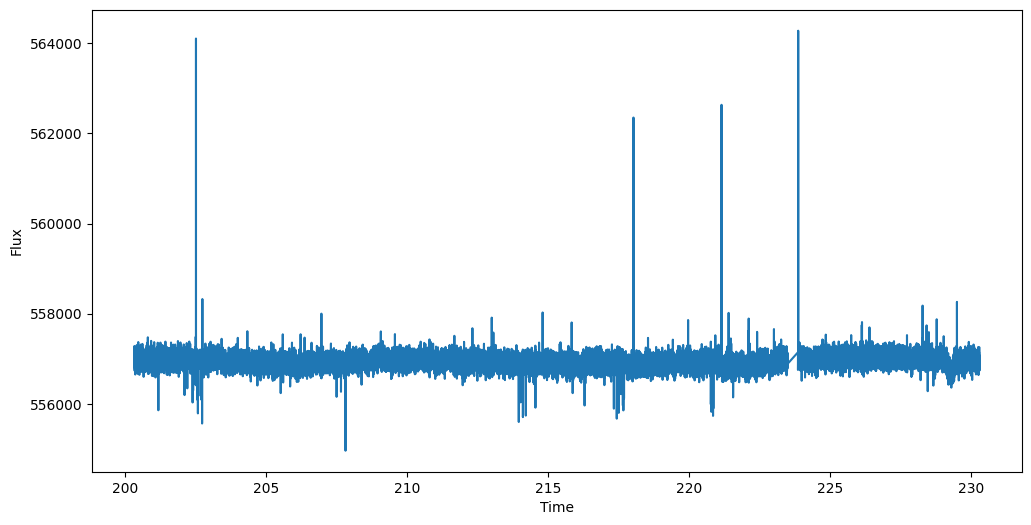

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['time'],df['flux'])
plt.xlabel('Time')
plt.ylabel('Flux')

In [ ]:
lc = lc.normalize().remove_nans()

In [ ]:
lc_flat = lc.flatten(window_length=101)

In [ ]:
if user_period is None:
    pg = lc_flat.to_periodogram()
    period = pg.period_at_max_power.value
    print("Estimated period (days):", period)
else:
    period = user_period
    print("Using user-given period (days):", period)

Estimated period (days): 0.034335987664376975


In [ ]:
folded_lc = lc_flat.fold(period=period)

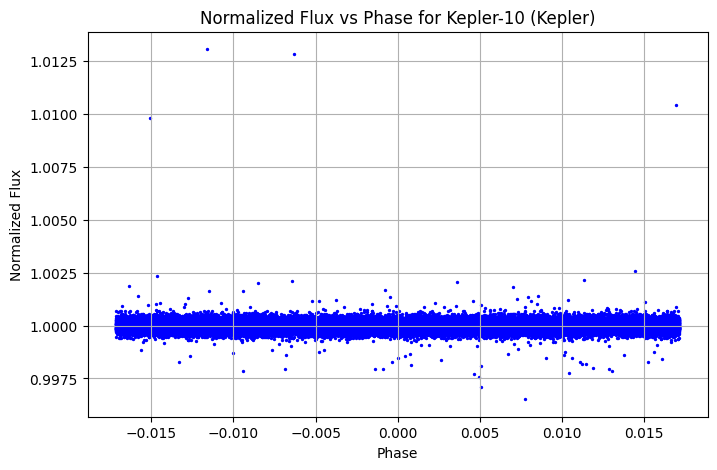

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(folded_lc.phase.value, folded_lc.flux.value, s=2, color="blue")
plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.title(f"Normalized Flux vs Phase for {star_name} ({mission_name})")
plt.grid(True)
plt.show()

## Conclusion
The analysis demonstrates application of Python-based techniques on astronomical data.

## Key Techniques Used
- Lightkurve
- Time Series Analysis
- Signal Processing
